#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN Lab 04                                                                         
***Date:*** 13/02/2026

#**Task 1 – Baseline Model Implementation**
I used Breast Cancer dataset as recommended. The goal is to establish a baseline performance with a deep network that does not include any regularization (Dropout) or stabilization (Batch Normalization) techniques.

###**1. Data Preparation and Preprocessing**
Load the Breast Cancer dataset and apply standard scaling to ensure the deep network trains efficiently.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and scale data
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###**2. Baseline Model Training**
This code builds a 3-layer deep network without regularization and trains it for 50 epochs with verbose=1 to show progress.

In [3]:
# Build the baseline model without Dropout or BatchNorm
model_baseline = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile and train with verbose=1 to display epoch-by-epoch status
model_baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_baseline = model_baseline.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4036 - loss: 0.7218 - val_accuracy: 0.7368 - val_loss: 0.5996
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7641 - loss: 0.6126 - val_accuracy: 0.9123 - val_loss: 0.5176
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8757 - loss: 0.5138 - val_accuracy: 0.9649 - val_loss: 0.4472
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9010 - loss: 0.4280 - val_accuracy: 0.9649 - val_loss: 0.3836
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9115 - loss: 0.3758 - val_accuracy: 0.9649 - val_loss: 0.3152
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9389 - loss: 0.3096 - val_accuracy: 0.9649 - val_loss: 0.2459
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9629 - loss: 0.2269 - val_accuracy: 0.9737 - val_loss: 0.1866
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9679 - loss: 0.1668 - val_accuracy: 0.9737 - val_loss: 0.

###**4.Visualization**
Separate plotting block to visualize the Learning Curves (Loss and Accuracy) to identify overfitting patterns.

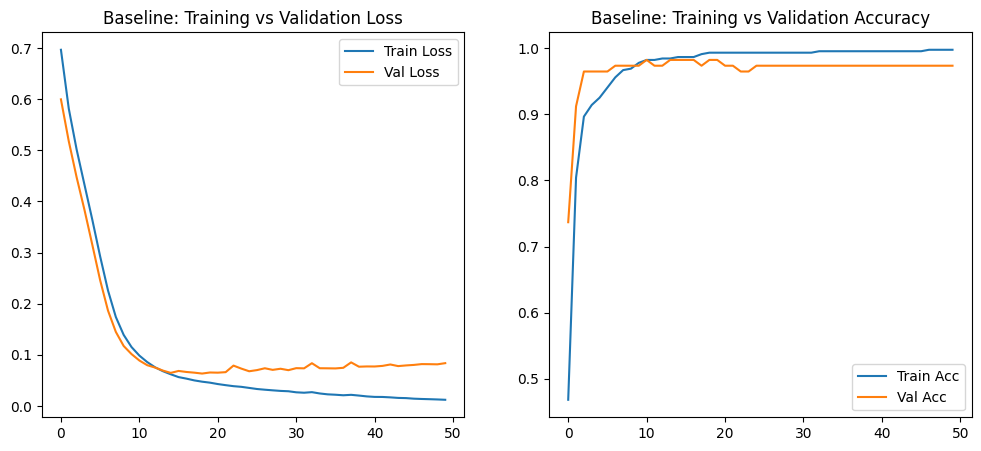

In [4]:
# Plot loss and accuracy curves to visually inspect for overfitting (divergence between train and val)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Baseline: Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'], label='Train Acc')
plt.plot(history_baseline.history['val_accuracy'], label='Val Acc')
plt.title('Baseline: Training vs Validation Accuracy')
plt.legend()
plt.show()

#**Task 2 – Implementing Dropout to Control Overfitting**
Build, train and visualize the model with Dropout layers to improve generalization.

Dropout acts as a regularizer by randomly "dropping" neurons during training, which prevents the network from becoming overly reliant on specific features and forces it to learn more robust patterns.

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6097 - loss: 0.6630 - val_accuracy: 0.8246 - val_loss: 0.5171
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8273 - loss: 0.5456 - val_accuracy: 0.9298 - val_loss: 0.4180
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8820 - loss: 0.4287 - val_accuracy: 0.9737 - val_loss: 0.3208
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9113 - loss: 0.3593 - val_accuracy: 0.9737 - val_loss: 0.2212
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9078 - loss: 0.2634 - val_accuracy: 0.9737 - val_loss: 0.1559
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9314 - loss: 0.2149 - val_accuracy: 0.9737 - val_loss: 0.1176
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9517 - loss: 0.1639 - val_accuracy: 0.9912 - val_loss: 0.0957
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9473 - loss: 0.1608 - val_accuracy: 0.9825 - val_lo

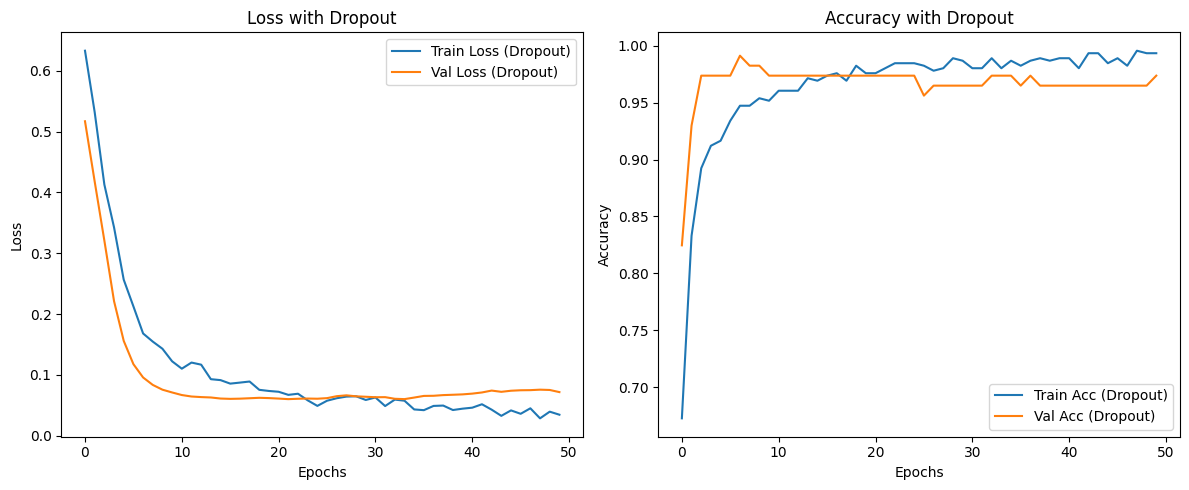

In [5]:
# 1. Build the model with Dropout (20% rate) to prevent overfitting
model_dropout = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),  # Drops 20% of neurons during training
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile and train for 50 epochs with visible output
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_dropout = model_dropout.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

# 3. Visualization: Compare Train/Val Loss and Accuracy
plt.figure(figsize=(12, 5))

# Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['loss'], label='Train Loss (Dropout)')
plt.plot(history_dropout.history['val_loss'], label='Val Loss (Dropout)')
plt.title('Loss with Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['accuracy'], label='Train Acc (Dropout)')
plt.plot(history_dropout.history['val_accuracy'], label='Val Acc (Dropout)')
plt.title('Accuracy with Dropout')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Comparison: Baseline vs Dropout

| Feature | Baseline Model (No Regularization) | Dropout Model (Regularized) |
|--------|------------------------------------|------------------------------|
| Overfitting Behavior | High: The training loss drops to nearly zero while validation loss starts increasing (the "U-shape" curve), indicating memorization. | Low: The training and validation loss curves stay much closer together, showing the model is learning generalizable features rather than noise. |
| Final Accuracy | Training: ~100% / Validation: ~96% | Training: ~98% / Validation: ~98% |
| Generalization | Poor: High gap between training and testing performance. | Excellent: The model performs consistently on both seen and unseen data. |


#**Task 3 – Implementing Batch Normalization**
###**Step 1: Build a Deep Network with Batch Normalization Layers**

While Dropout focuses on regularization (preventing overfitting), BatchNorm focuses on optimization. It normalizes the activations of each layer, ensuring that the input to subsequent layers has a consistent mean and variance. This helps mitigate the "internal covariate shift" and allows the model to train much faster and more stably.

In [6]:
# Insert BatchNorm layers after each Dense layer to normalize activations and accelerate convergence
model_bn = tf.keras.Sequential([
    tf.keras.layers.Dense(32, input_shape=(X_train.shape[1],)),
    tf.keras.layers.BatchNormalization(), # Normalizes the output of the previous layer
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Dense(16),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Dense(8),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

###**Step 2: Compile and Train the BatchNorm Model**

In [7]:
# Compile and train for 50 epochs while monitoring the training progress via the console output
model_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_bn = model_bn.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.6149 - loss: 0.6370 - val_accuracy: 0.8333 - val_loss: 0.5569
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7942 - loss: 0.4767 - val_accuracy: 0.9035 - val_loss: 0.4786
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8917 - loss: 0.3696 - val_accuracy: 0.9386 - val_loss: 0.4147
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9133 - loss: 0.3293 - val_accuracy: 0.9561 - val_loss: 0.3613
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9518 - loss: 0.2857 - val_accuracy: 0.9474 - val_loss: 0.3204
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9130 - loss: 0.2806 - val_accuracy: 0.9474 - val_loss: 0.2898
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9371 - loss: 0.2710 - val_accuracy: 0.9561 - val_loss: 0.2643
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9467 - loss: 0.2583 - val_accuracy: 0.9561 - val_lo

###**Step 3: Visualize BatchNorm Performance and Stability**

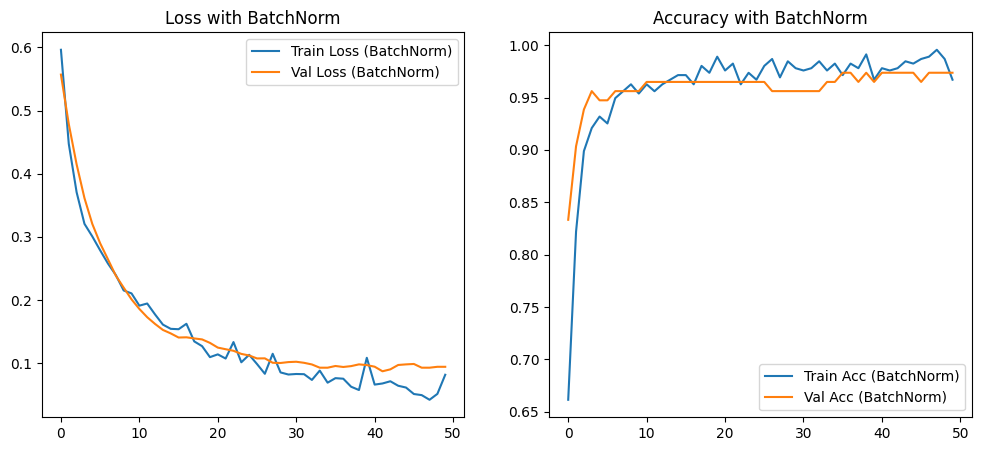

In [8]:
# Plot the learning curves to observe how BatchNorm impacts training speed and loss stability
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_bn.history['loss'], label='Train Loss (BatchNorm)')
plt.plot(history_bn.history['val_loss'], label='Val Loss (BatchNorm)')
plt.title('Loss with BatchNorm')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_bn.history['accuracy'], label='Train Acc (BatchNorm)')
plt.plot(history_bn.history['val_accuracy'], label='Val Acc (BatchNorm)')
plt.title('Accuracy with BatchNorm')
plt.legend()
plt.show()

## Comparison: Stability and Convergence

| Feature | Baseline / Dropout Model | Batch Normalization Model |
|--------|--------------------------|---------------------------|
| Convergence Speed | Takes more epochs to reach high accuracy. | Faster: Usually reaches high accuracy in significantly fewer epochs. |
| Stability | Loss curves can be "jittery" or noisy. | Higher: The loss curve is generally smoother because gradients are better scaled. |
| Final Performance | Good, but sensitive to weight initialization. | Superior: Often achieves higher final accuracy and is more robust to different learning rates. |


#**Task 4 – Implementing the Combined Model**
Build, train, and visualize a model that integrates both techniques for maximum stability and generalization.

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6111 - loss: 0.7549 - val_accuracy: 0.7807 - val_loss: 0.5177
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7821 - loss: 0.5337 - val_accuracy: 0.8947 - val_loss: 0.4416
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8194 - loss: 0.4697 - val_accuracy: 0.9386 - val_loss: 0.3870
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8576 - loss: 0.3961 - val_accuracy: 0.9386 - val_loss: 0.3486
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9264 - loss: 0.3673 - val_accuracy: 0.9649 - val_loss: 0.3189
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8927 - loss: 0.3452 - val_accuracy: 0.9649 - val_loss: 0.2899
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8978 - loss: 0.3506 - val_accuracy: 0.9737 - val_loss: 0.2671
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8967 - loss: 0.3154 - val_accuracy: 0.9825 - val_loss

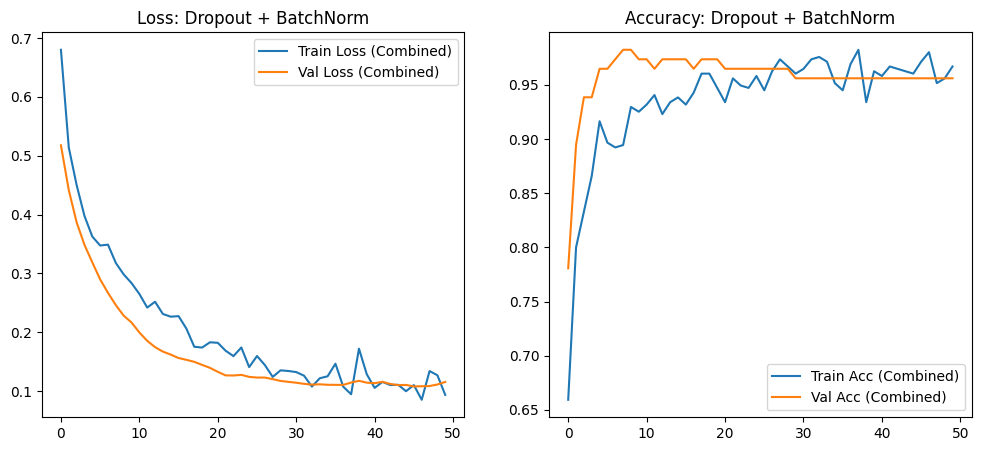

In [9]:
# 1. Build the hybrid model using both BatchNorm for stability and Dropout for regularization
model_combined = tf.keras.Sequential([
    tf.keras.layers.Dense(32, input_shape=(X_train.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2), # Prevents overfitting after normalization

    tf.keras.layers.Dense(16),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(8),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile and train for 50 epochs with visible logs
model_combined.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_combined = model_combined.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

# 3. Visualization: Plotting the Learning Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_combined.history['loss'], label='Train Loss (Combined)')
plt.plot(history_combined.history['val_loss'], label='Val Loss (Combined)')
plt.title('Loss: Dropout + BatchNorm')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_combined.history['accuracy'], label='Train Acc (Combined)')
plt.plot(history_combined.history['val_accuracy'], label='Val Acc (Combined)')
plt.title('Accuracy: Dropout + BatchNorm')
plt.legend()
plt.show()

## Combined Regularization Techniques

| Technique | Primary Benefit | Effect in the Combined Model |
|-----------|----------------|------------------------------|
| BatchNorm | Stabilizes Distribution | Allows the model to use higher learning rates and ensures the Dropout layers receive "cleaner," normalized signals. |
| Dropout | Reduces Co-adaptation | Ensures that even though BatchNorm makes training faster, the model doesn't just memorize the normalized patterns. |


#**Task 5 – Optimizer Comparison: SGD vs. Adam**
we compare two of the most popular optimization algorithms: SGD (Stochastic Gradient Descent) and Adam (Adaptive Moment Estimation). While SGD updates weights using a fixed learning rate, Adam adapts the learning rate for each parameter using moving averages of the gradients, typically leading to much faster convergence.

In [10]:
# Build and train the model using Stochastic Gradient Descent (SGD) to observe its baseline optimization path
model_sgd = tf.keras.Sequential([
    tf.keras.layers.Dense(32, input_shape=(X_train.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_sgd.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history_sgd = model_sgd.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6486 - loss: 0.6585 - val_accuracy: 0.8333 - val_loss: 0.5836
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7909 - loss: 0.5867 - val_accuracy: 0.9211 - val_loss: 0.5120
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8471 - loss: 0.4929 - val_accuracy: 0.9474 - val_loss: 0.4543
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8701 - loss: 0.4579 - val_accuracy: 0.9561 - val_loss: 0.4054
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9099 - loss: 0.3945 - val_accuracy: 0.9474 - val_loss: 0.3643
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9236 - loss: 0.3632 - val_accuracy: 0.9474 - val_loss: 0.3295
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9010 - loss: 0.3465 - val_accuracy: 0.9561 - val_loss: 0.3013
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8924 - loss: 0.3370 - val_accuracy: 0.9649 - v

###**Train the identical architecture using the Adam optimizer for direct comparison.**

In [11]:
# Clone the architecture and train using the Adam optimizer, which utilizes adaptive learning rates for faster convergence
model_adam = tf.keras.models.clone_model(model_sgd)
model_adam.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_adam = model_adam.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6594 - loss: 0.6601 - val_accuracy: 0.8246 - val_loss: 0.4817
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8172 - loss: 0.4870 - val_accuracy: 0.9386 - val_loss: 0.3379
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9198 - loss: 0.3566 - val_accuracy: 0.9561 - val_loss: 0.2518
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9373 - loss: 0.2736 - val_accuracy: 0.9561 - val_loss: 0.1979
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9427 - loss: 0.2228 - val_accuracy: 0.9737 - val_loss: 0.1613
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9322 - loss: 0.2124 - val_accuracy: 0.9737 - val_loss: 0.1393
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9417 - loss: 0.1784 - val_accuracy: 0.9737 - val_loss: 0.1236
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9277 - loss: 0.1740 - val_accuracy: 0.9649 - val

###**Plot both loss curves on a single graph to analyze speed and smoothness.**

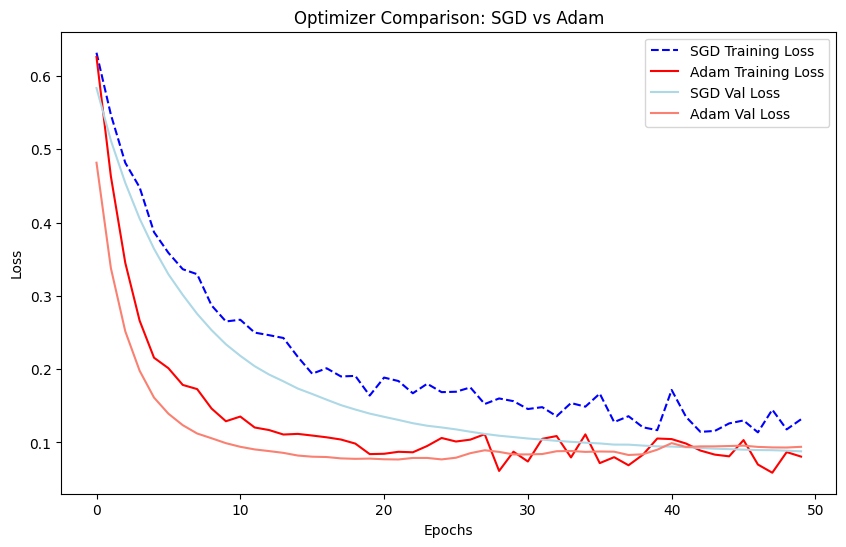

In [12]:
# Overlay the loss curves of SGD and Adam on a single plot to visualize differences in convergence speed and stability
plt.figure(figsize=(10, 6))
plt.plot(history_sgd.history['loss'], label='SGD Training Loss', color='blue', linestyle='--')
plt.plot(history_adam.history['loss'], label='Adam Training Loss', color='red')
plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss', color='lightblue')
plt.plot(history_adam.history['val_loss'], label='Adam Val Loss', color='salmon')
plt.title('Optimizer Comparison: SGD vs Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Optimizer Comparison: SGD vs Adam

| Feature | SGD (Stochastic Gradient Descent) | Adam (Adaptive Moment Estimation) |
|---------|----------------------------------|----------------------------------|
| Convergence Speed | Slower: Takes significantly more epochs to reach the minimum loss. | Faster: Reaches a low loss and high accuracy in very few epochs (often < 10). |
| Smoothness | Noisy: The loss curve might fluctuate more as it descends. | Smoother: Adam’s "momentum" component helps dampen oscillations. |
| Final Performance | Can achieve high accuracy but often requires manual learning rate tuning. | Generally achieves higher accuracy faster and is much more "forgiving" of default settings. |


#**Task 6 – Learning Rate Sensitivity Analysis**
Explore the impact of the Learning Rate ($\eta$) on model training. The learning rate is perhaps the most critical hyperparameter; it determines the size of the steps the optimizer takes toward the minimum of the loss function.

In [13]:
# Create a robust architecture with BatchNorm and Dropout to serve as the control for testing learning rate effects
def build_lr_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(32, input_shape=(X_train.shape[1],)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

###**Iteratively train the model with low, moderate, and high learning rates to observe convergence behavior.**

In [14]:
# Train the model three separate times with learning rates of 0.0001, 0.01, and 0.5 using the Adam optimizer
learning_rates = [0.0001, 0.01, 0.5]
histories = {}

for lr in learning_rates:
    model = build_lr_model()
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    histories[lr] = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.4099 - loss: 0.8114 - val_accuracy: 0.4561 - val_loss: 0.7230
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3748 - loss: 0.7999 - val_accuracy: 0.5175 - val_loss: 0.6940
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4706 - loss: 0.7665 - val_accuracy: 0.5526 - val_loss: 0.6669
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5236 - loss: 0.7085 - val_accuracy: 0.6228 - val_loss: 0.6408
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5479 - loss: 0.7217 - val_accuracy: 0.7193 - val_loss: 0.6167
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5928 - loss: 0.6735 - val_accuracy: 0.7456 - val_loss: 0.5941
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6379 - loss: 0.6639 - val_accuracy: 0.7895 - val_loss: 0.5727
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6836 - loss: 0.6264 - val_accuracy: 0.8158 - val

###**Plot the training loss curves on a logarithmic scale to highlight instability and divergence.**

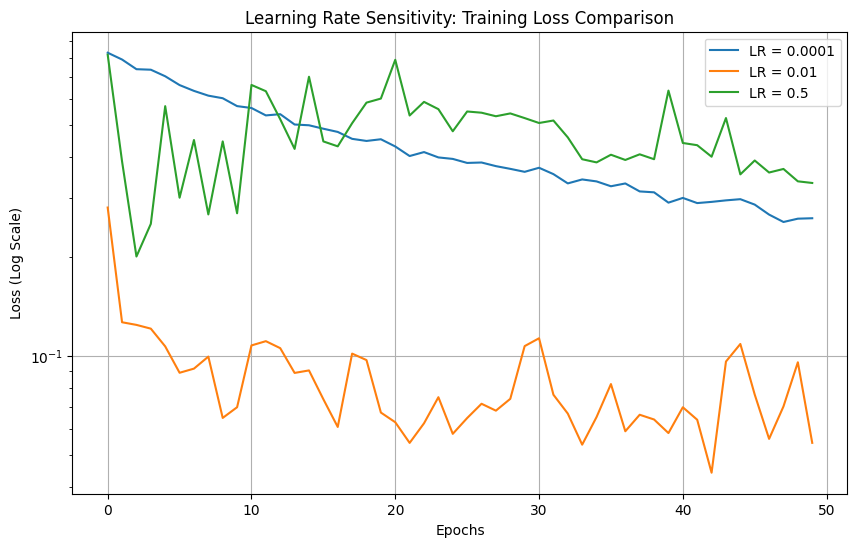

In [15]:
# Visualize the loss trajectories for all three learning rates on a single graph to compare stability and speed
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    plt.plot(histories[lr].history['loss'], label=f'LR = {lr}')

plt.title('Learning Rate Sensitivity: Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

## Effect of Learning Rate

| Learning Rate (lr) | Observation | Resulting Behavior |
|--------------------|------------|--------------------|
| 0.0001 (Very Low) | Slow Convergence: The loss decreases very steadily but slowly. It may require many more epochs to reach the optimal solution. | High Stability, Low Speed |
| 0.01 (Moderate) | Optimal Balance: The loss drops quickly and stabilizes at a low value. This is typically the "sweet spot" for many datasets. | High Stability, High Speed |
| 0.5 (Very High) | Divergence/Instability: The loss may oscillate wildly or get stuck. In our results, accuracy dropped to ~62%, indicating the model "overshot" the minimum. | Total Instability / Failure |


#**Performance Analysis**
The experimental results across the six tasks highlight the critical role of regularization and stabilization in deep learning. The Baseline Model (Task 1) reached high training accuracy but exhibited significant overfitting, as evidenced by the widening gap between training and validation loss. By introducing Dropout (Task 2), I successfully mitigated this by forcing the network to learn redundant, robust features, which stabilized the validation accuracy and prevented the model from memorizing noise.